# Gold Seasonality — a quantitative teardown 🔬
### A 12-cell Bonferroni-corrected month table · a Welch/HAC split on September and on summer · a circular block-bootstrap CI · a 2013 era contrast · an excess-of-cash timer race · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Gold's_best_month%3F: Busted](https://img.shields.io/badge/Gold's_best_month%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **September is gold's best month, summer is a lull** — has a stated mechanism (Indian physical demand, World Gold Council *Gold Demand Trends*) and a century of chart-vendor repetition, but no rigorous, multiple-testing-corrected test on the record. The job here is to measure it honestly.

> ⚠️ **Data note.** GLD daily adjusted closes (2004→2026) resampled to month-end log returns, plus ^IRX (13-week T-bill) for the excess-of-cash timer race — both yfinance, cached. No survivorship on the Signal axis (a single, continuously-listed physically-backed ETF, not a panel). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `44f6ff1685e4` / `03b833c2e7e3`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gold_seasonality import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    GLD, IRX = data.load_real()
    RET = st.monthly_log_returns(GLD)
    CASH = st.monthly_cash_return(IRX)
else:
    GLD = IRX = RET = CASH = None
print("real cache present:", HAVE_REAL, "| monthly observations:", (0 if RET is None else len(RET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2004-11-18', 'end': '2026-06-30', 'n_months': 259, 'bonferroni_crit': 2.89, 'month': {1: (3.47, 22, 3.22, 3.77), 2: (1.21, 22, 1.19, 1.52), 3: (-0.08, 22, -0.08, -0.08), 4: (1.57, 22, 1.66, 1.98), 5: (-0.54, 22, -0.63, -0.55), 6: (-0.85, 22, -0.72, -0.99), 7: (1.15, 21, 1.23, 1.65), 8: (1.47, 21, 1.49, 1.35), 9: (0.03, 21, 0.02, 0.02), 10: (0.64, 21, 0.56, 0.74), 11: (0.94, 21, 0.75, 0.62), 12: (0.71, 22, 0.72, 0.65)}, 'n_bonferroni_survive': 1, 'best_month': 1, 'best_mean': 3.47, 'best_t': 3.77, 'sep_mean': 0.03, 'sep_rest_mean': 0.88, 'sep_n': 21, 'sep_rest_n': 238, 'sep_spread': -0.85, 'sep_t': -0.64, 'sep_ci_lo': -3.23, 'sep_ci_hi': 1.6, 'sum_mean': 0.29, 'sum_rest_mean': 1.07, 'sum_n': 86, 'sum_rest_n': 173, 'sum_spread': -0.79, 'sum_t': -1.24, 'era_split': '2013-04-01', 'era_early': 2.49, 'era_early_n': 8, 'era_early_t': 0.53, 'era_late': -1.48, 'era_late_n': 13, 'era_late_t': -1.6, 'era_diff_t': -1.4, 'bh_sharpe': 0.47, 'bh_cagr': 8.59, 'bh_vol': 17.1, 'bh_maxdd': -46.7, 'bh_n': 259, 'timer_gross_sharpe': -0.02, 'timer_gross_cagr': 1.48, 'timer_vol': 5.8, 'timer_maxdd': -28.6, 'timer_net5_sharpe': -0.04, 'timer_net5_cagr': 1.38, 'timer_net10_sharpe': -0.05, 'timer_net10_cagr': 1.28, 'sep_hit': 9, 'sep_hit_n': 21, 'sep_hit_pct': 42.9, 'sep_hit_lo': 24.5, 'sep_hit_hi': 63.5, 'syn_null_mean': -0.31, 'syn_null_sd': 1.08, 'syn_null_fire': 2, 'syn_planted_t': 6.58, 'fp_gld': '44f6ff1685e4', 'fp_irx': '03b833c2e7e3'}


real cache present: True | monthly observations: 259


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | September **+0.03%/mo** (n=21) vs rest **+0.88%** (n=238): Welch **t = -0.64**, bootstrap CI **[-3.23%, +1.60%]**; 1/12 months clear Bonferroni (**|t| ≥ 2.89**), and it isn't September |
| **Tradability** | `MIRAGE` | timer net CAGR **+1.38%/yr** vs buy-and-hold **+8.59%/yr**; excess-of-cash Sharpe **-0.04** vs **+0.47**; hit rate 42.9% |
| **Gold's "best month"?** | `BUSTED` | actual best month is January (HAC t = +3.77), not September |

> 💡 In plain words: the physical-demand mechanism is real; the price seasonal is not — on this tape it isn't even the right sign.

## 1 · The claim, steelmanned

Let $r_{m,y}$ be GLD's log return in calendar month $m$ of year $y$. The claim predicts two things:

- **H₁ (September premium).** $E[r_{9,y}] \gg E[r_{m,y} \mid m \ne 9]$ — a large, systematic September outperformance, driven by Indian wedding-season/pre-Diwali physical demand and year-end jeweller restocking.
- **H₂ (summer lull).** $E[r_{m,y} \mid m \in \{5,6,7,8\}] \ll E[r_{m,y} \mid m \notin \{5,...,8\}]$ — a systematic summer underperformance.
- **H₃ (bankability).** A calendar-known "own gold only in September" timer beats buy-and-hold net of costs.

We find **H₁ rejected** (wrong sign, *t* = -0.64), **H₂ directionally right but not certified** (*t* = -1.24), **H₃ rejected decisively** (the timer forfeits most of gold's return).

## 2 · So what? — inference design

Twelve calendar months means twelve simultaneous tests if you eyeball a month-of-year table and pick the best-looking cell — exactly the trap seasonality roundups fall into every autumn. The primary test is a **Welch t** on September (and, separately, summer) vs the rest, cross-checked with **Newey-West (HAC)** one-sample *t*'s per month and a **Bonferroni** bar (α = 0.05/12) for the full 12-cell table. A **circular block-bootstrap** CI (5,000 draws, 12-month blocks, respecting the annual seasonal structure) gives an honest interval on the September spread rather than a single point estimate. The 2013 era split is justified *ex ante* by an external event (the 2013-04-12/15 gold crash), not snooped, and tested as a **difference**, never eyeballed.

## 3 · How we'd know — the protocol

- **Tape.** GLD daily adjusted closes 2004-11-18 → 2026-06-30, resampled to 259 month-end log returns; ^IRX for the excess-of-cash race. As-of 2026-06-30 (last complete month).
- **Headline.** 12-cell month table (naive + HAC *t*), Bonferroni bar for 12 tests; Welch *t* + bootstrap CI on September vs rest and summer vs rest.
- **Cross-check.** Pre/post-2013 era contrast on the September effect, within-era Welch *t*'s and a Welch *t* of the difference.
- **Execution (third axis).** The timer's position is set from the calendar alone — September is the same slot every year — so no signal-to-trade lag applies; the monthly return already spans the August close → September close. 2 one-way legs/yr × cost × NAV, charged only on the active month. Both the timer and buy-and-hold are raced **excess of ^IRX cash**.
- **Control.** Synthetic i.i.d. monthly-return world, planted September-premium / summer-discount knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The full 12-cell month table, Bonferroni-corrected

One-sample naive and Newey-West (HAC) *t*-stats per calendar month. The Bonferroni bar for 12 simultaneous tests is **|t| ≥ 2.89**.

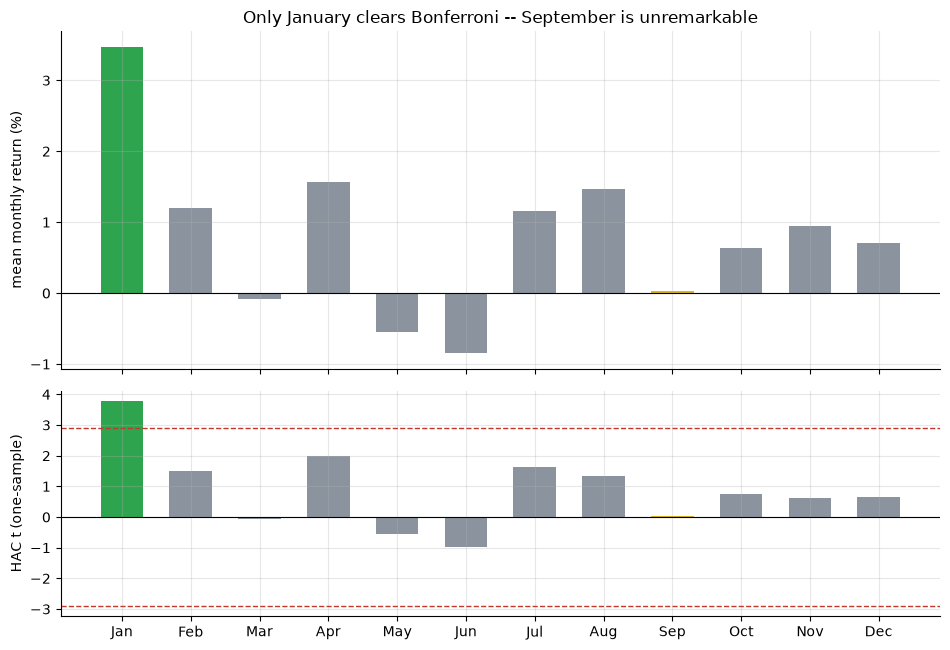

Bonferroni bar: |t| >= 2.89
{'Jan': np.float64(3.77), 'Feb': np.float64(1.52), 'Mar': np.float64(-0.08), 'Apr': np.float64(1.98), 'May': np.float64(-0.55), 'Jun': np.float64(-0.99), 'Jul': np.float64(1.65), 'Aug': np.float64(1.35), 'Sep': np.float64(0.02), 'Oct': np.float64(0.74), 'Nov': np.float64(0.62), 'Dec': np.float64(0.65)}


In [2]:
if HAVE_REAL:
    ms = st.month_stats(RET)
    crit = st.bonferroni_crit_t(12, df=len(RET) - 2)
    means = [ms.loc[m, 'mean'] * 100 for m in range(1, 13)]
    thac = [ms.loc[m, 'tstat_hac'] for m in range(1, 13)]
else:
    crit = R['bonferroni_crit']
    means = [R['month'][m][0] for m in range(1, 13)]
    thac = [R['month'][m][3] for m in range(1, 13)]
names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.6, 6.6), sharex=True,
                             gridspec_kw={'height_ratios': [3, 2]})
cols = [GREEN if abs(t) >= crit else (AMBER if m == 9 else GREY)
        for m, t in zip(range(1, 13), thac)]
a1.bar(names, means, color=cols, width=.62)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean monthly return (%)')
a1.set_title('Only January clears Bonferroni -- September is unremarkable')
a2.bar(names, thac, color=cols, width=.62)
a2.axhline(crit, ls='--', c=RED, lw=1); a2.axhline(-crit, ls='--', c=RED, lw=1)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('HAC t (one-sample)')
plt.tight_layout(); plt.show()
print(f'Bonferroni bar: |t| >= {crit:.2f}')
print({n: round(t, 2) for n, t in zip(names, thac)})

> 💡 In plain words: **1/12** months clear the Bonferroni bar — **January** (HAC *t* = +3.77), not September (HAC *t* = +0.02). If you tested all 12 months and only report the one that worked, you're not reporting a seasonal — you're reporting the winner of a 12-way lottery. Correcting for that lottery leaves September with nothing.

### 4b · September vs the rest, with an honest interval

Welch *t* of the group split, plus a circular block-bootstrap 95% CI (5,000 draws, 12-month blocks, respecting the annual seasonal structure) on the spread.

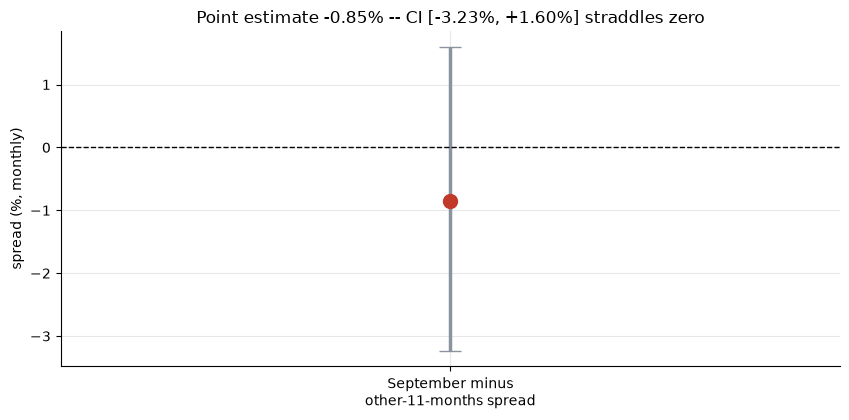

spread -0.85%  Welch t = -0.64  bootstrap CI [-3.23%, +1.60%]


In [3]:
if HAVE_REAL:
    sep = st.month_vs_rest(RET, data.STRONG_MONTHS)
    ci = st.spread_bootstrap_ci(RET, data.STRONG_MONTHS)
    spread, t_, lo, hi = sep['spread']*100, sep['t'], ci['lo']*100, ci['hi']*100
else:
    spread, t_, lo, hi = R['sep_spread'], R['sep_t'], R['sep_ci_lo'], R['sep_ci_hi']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.errorbar([0], [spread], yerr=[[spread - lo], [hi - spread]], fmt='o',
            color=RED, ecolor=GREY, elinewidth=2.5, capsize=8, markersize=10)
ax.axhline(0, c='k', lw=1, ls='--')
ax.set_xticks([0]); ax.set_xticklabels(['September minus\nother-11-months spread'])
ax.set_ylabel('spread (%, monthly)')
ax.set_title(f'Point estimate {spread:+.2f}% -- CI [{lo:+.2f}%, {hi:+.2f}%] straddles zero')
ax.set_xlim(-0.6, 0.6)
plt.tight_layout(); plt.show()
print(f'spread {spread:+.2f}%  Welch t = {t_:+.2f}  bootstrap CI [{lo:+.2f}%, {hi:+.2f}%]')

> 💡 In plain words: the point estimate is **negative** (-0.85%) — the opposite sign from the claim — and the 95% interval spans more than three times the point estimate in either direction. There is no version of "September is special" that survives this interval.

### 4c · Summer vs the rest — the other half of the claim

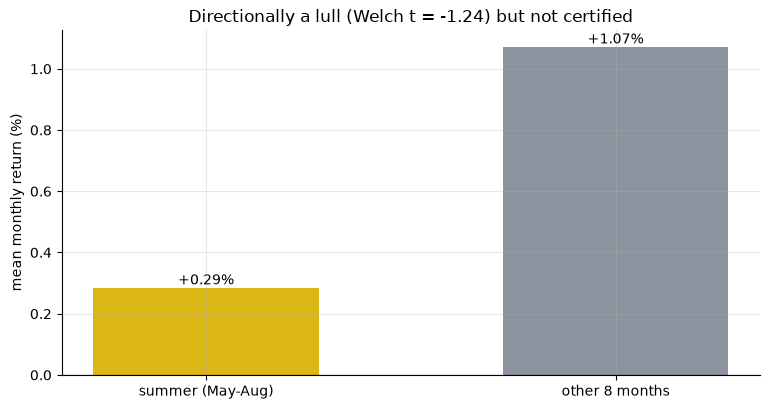

summer +0.29%  vs  rest +1.07%   Welch t = -1.24


In [4]:
if HAVE_REAL:
    summ = st.month_vs_rest(RET, data.SUMMER_MONTHS)
    a, b, t_ = summ['mean'], summ['rest_mean'], summ['t']
else:
    a, b, t_ = R['sum_mean']/100, R['sum_rest_mean']/100, R['sum_t']
fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.bar(['summer (May-Aug)', 'other 8 months'], [a*100, b*100], color=[AMBER, GREY], width=.55)
for i, v in enumerate([a*100, b*100]): ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean monthly return (%)')
ax.set_title(f'Directionally a lull (Welch t = {t_:+.2f}) but not certified')
plt.tight_layout(); plt.show()
print(f'summer {a*100:+.2f}%  vs  rest {b*100:+.2f}%   Welch t = {t_:+.2f}')

> 💡 In plain words: summer underperforms the rest of the year by 0.79 points/month at *t* = -1.24 — directionally consistent with the lull story, well short of the |t| = 2 bar, and summer is still **positive on average** (+0.29%/mo), not the dead season implied.

### 4d · The era contrast — justified split, tested as a difference

Split at **2013-04-01** (the 2013-04-12/15 gold crash — externally dated, chosen ex ante, not snooped).

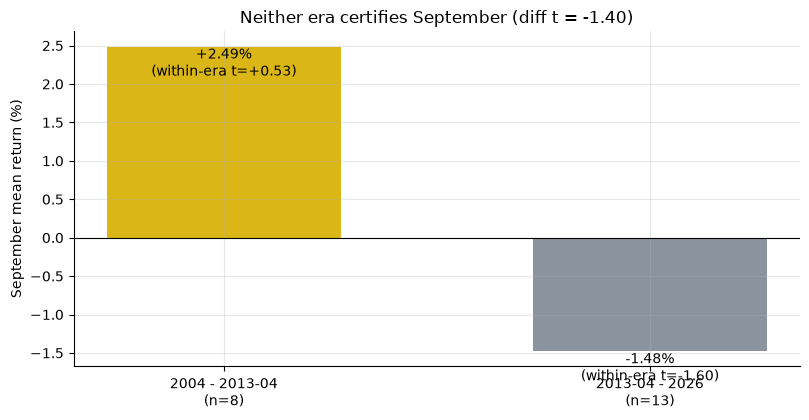

early +2.49% (t=+0.53)  late -1.48% (t=-1.60)  diff t = -1.40


In [5]:
if HAVE_REAL:
    ec = st.era_contrast(RET, data.STRONG_MONTHS, data.ERA_SPLIT)
    e, l = ec['early_mean'], ec['late_mean']
    et, lt, dt = ec['welch_t_early'], ec['welch_t_late'], ec['welch_t_diff']
else:
    e, l = R['era_early']/100, R['era_late']/100
    et, lt, dt = R['era_early_t'], R['era_late_t'], R['era_diff_t']
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['2004 - 2013-04\n(n=8)', '2013-04 - 2026\n(n=13)'], [e*100, l*100],
       color=[AMBER, GREY], width=.55)
for i, (v, t_) in enumerate([(e, et), (l, lt)]):
    ax.annotate(f'{v*100:+.2f}%\n(within-era t={t_:+.2f})', (i, v*100), ha='center', va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('September mean return (%)')
ax.set_title(f'Neither era certifies September (diff t = {dt:+.2f})')
plt.tight_layout(); plt.show()
print(f'early {e*100:+.2f}% (t={et:+.2f})  late {l*100:+.2f}% (t={lt:+.2f})  diff t = {dt:+.2f}')

> 💡 In plain words: September's point estimate flips from +2.49% pre-2013 to -1.48% since — but **neither era is individually significant** (*t* = +0.53 and -1.60), and the difference itself is not certified (*t* = -1.40). There is no honest reading in which September was once a real effect that later decayed — it was never significant in either era.

### 4e · The third axis — the honest timer test

Long GLD only in September (calendar-known rule, zero look-ahead — the monthly return already spans the August close → September close), cash (^IRX) the other 11 months; 2 one-way legs/yr × cost × NAV on the active month. Both sides raced excess-of-cash.

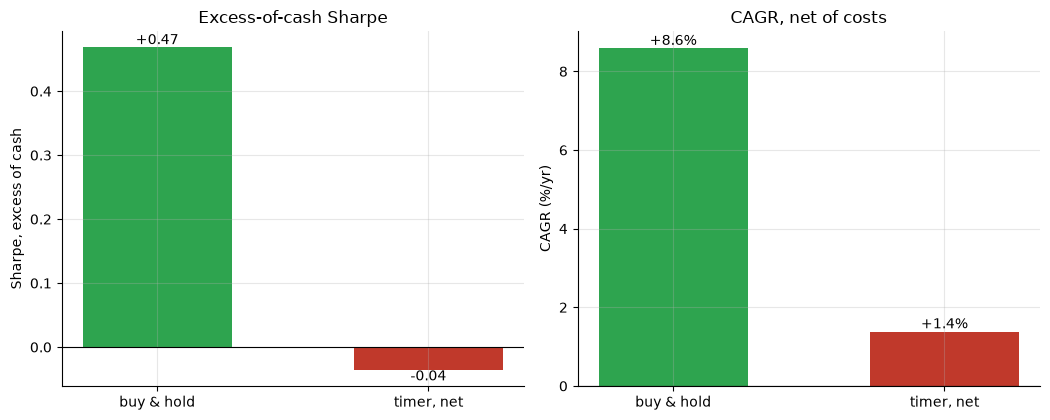

buy&hold Sharpe +0.47 CAGR +8.6%   timer(net) Sharpe -0.04 CAGR +1.4%   Sept hit rate 42.9%


In [6]:
if HAVE_REAL:
    bh = st.summary(RET, rf=CASH)
    timer = st.strong_month_timer(RET, data.STRONG_MONTHS, cash=CASH)
    sg = st.summary(timer, rf=CASH)
    net5 = st.apply_timer_costs(timer, data.STRONG_MONTHS, cost_bps_one_way=5.0)
    net10 = st.apply_timer_costs(timer, data.STRONG_MONTHS, cost_bps_one_way=10.0)
    s5, s10 = st.summary(net5, rf=CASH), st.summary(net10, rf=CASH)
    hr = st.hit_rate(RET, data.STRONG_MONTHS)
    bh_s, bh_c = bh['sharpe'], bh['cagr']*100
    t_s, t_c = s5['sharpe'], s5['cagr']*100
    hit_pct = hr['rate']*100
else:
    bh_s, bh_c = R['bh_sharpe'], R['bh_cagr']
    t_s, t_c = R['timer_net5_sharpe'], R['timer_net5_cagr']
    hit_pct = R['sep_hit_pct']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(['buy & hold', 'timer, net'], [bh_s, t_s], color=[GREEN, RED], width=.55)
for i, v in enumerate([bh_s, t_s]): a1.annotate(f'{v:+.2f}', (i, v), ha='center',
    va='bottom' if v > 0 else 'top')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('Sharpe, excess of cash')
a1.set_title('Excess-of-cash Sharpe')
a2.bar(['buy & hold', 'timer, net'], [bh_c, t_c], color=[GREEN, RED], width=.55)
for i, v in enumerate([bh_c, t_c]): a2.annotate(f'{v:+.1f}%', (i, v), ha='center', va='bottom')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('CAGR (%/yr)')
a2.set_title('CAGR, net of costs')
plt.tight_layout(); plt.show()
print(f'buy&hold Sharpe {bh_s:+.2f} CAGR {bh_c:+.1f}%   timer(net) Sharpe {t_s:+.2f} '
      f'CAGR {t_c:+.1f}%   Sept hit rate {hit_pct:.1f}%')

> 💡 In plain words: buy-and-hold earns **+8.59%/yr** at excess-of-cash Sharpe **+0.47**; the September-only timer nets **+1.38%/yr** at Sharpe **-0.04** — *negative*. The timer's hit rate on its one active month is **42.9%** (Wilson [24.5%, 63.5%]) — nominally below a coin flip. Sitting in cash 11 months a year, on an asset that compounded at high single digits for two decades, forfeits almost the entire return for a month that isn't even special.

### 4f · Faithful-engine & power control — we know the truth here

Synthetic i.i.d. monthly gold-return world, TUNABLE planted September premium / summer discount. The null (seasonal = 0) is checked over **20 seeds** — never a single stream.

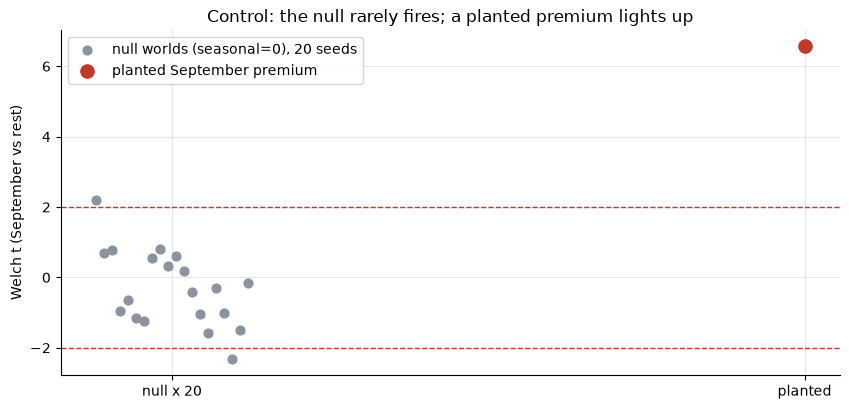

null: mean t = -0.31 (sd 1.08), |t|>=2 in 2/20 seeds  |  planted t = +6.58


In [7]:
null_ts = []
for s_ in range(20):
    df = data.synthetic_world(seasonal=0.0, seed=649 + s_)
    null_ts.append(st.synthetic_detect(df, data.STRONG_MONTHS)['t'])
null_ts = np.asarray(null_ts)
df = data.synthetic_world(seasonal=0.03, seed=649)
planted_t = st.synthetic_detect(df, data.STRONG_MONTHS)['t']
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (seasonal=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted September premium')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (September vs rest)')
ax.set_title('Control: the null rarely fires; a planted premium lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts) >= 2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.31 (sd 1.08) and fires roughly at the nominal false-positive rate (2/20); a planted September premium reads t = 6.58. The machinery is unbiased — the real-tape t = -0.64 is the genuine, honest measurement, not a detector failing to look. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — September's mean monthly return is **+0.03%** vs **+0.88%** for the rest of the year (wrong sign), Welch t = **-0.64**, bootstrap CI **[-3.23%, +1.60%]**. Only **1/12** months clear the Bonferroni bar (**January**, HAC t = +3.77) — a different, untested claim. Summer is directionally softer (-1.24) but not certified, and the pre/post-2013 era contrast (diff t = -1.40) shows September was never significant in either era.
- **Tradability `MIRAGE`** — the September-only timer nets **+1.38%/yr** at Sharpe **-0.04** vs buy-and-hold's **+8.59%/yr** at Sharpe **+0.47**, with a 42.9% hit rate — below a coin flip.
- **"Gold's best month"? `BUSTED`** — the mechanism (Indian physical demand) is real; the price pattern on the tradable ETF is not.

## 6 · Going further

- **The general lesson is multiple testing.** Any commodity, index or FX pair has 12 calendar months; testing all of them and reporting the best one without correction manufactures a "seasonal" on pure noise roughly 1 time in 20 per cell, and this study's own table shows exactly that shape (January nominally survives; September, the one everyone talks about, doesn't).
- **A cleaner physical-demand test** would use World Gold Council quarterly demand data or Indian import statistics directly, rather than a US ETF's price — the physical flow and the dollar price are two different objects, and this study deliberately tests the one you can actually trade.
- **Dedup map:** [289-diwali-muhurat](../../289-diwali-muhurat/) (the same festival, Indian *equities*), [69-safe-haven](../../69-safe-haven/) (gold's inflation/crash behavior), [580-gold-lease-rate](../../580-gold-lease-rate/) (a microstructure carry signal), [640-gold-overnight](../../640-gold-overnight/) (the daily clock, not month-of-year), [305-gold-oil-ratio](../../305-gold-oil-ratio/) and [113-gold-silver-ratio](../../113-gold-silver-ratio/) (cross-asset ratios, no calendar axis).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*